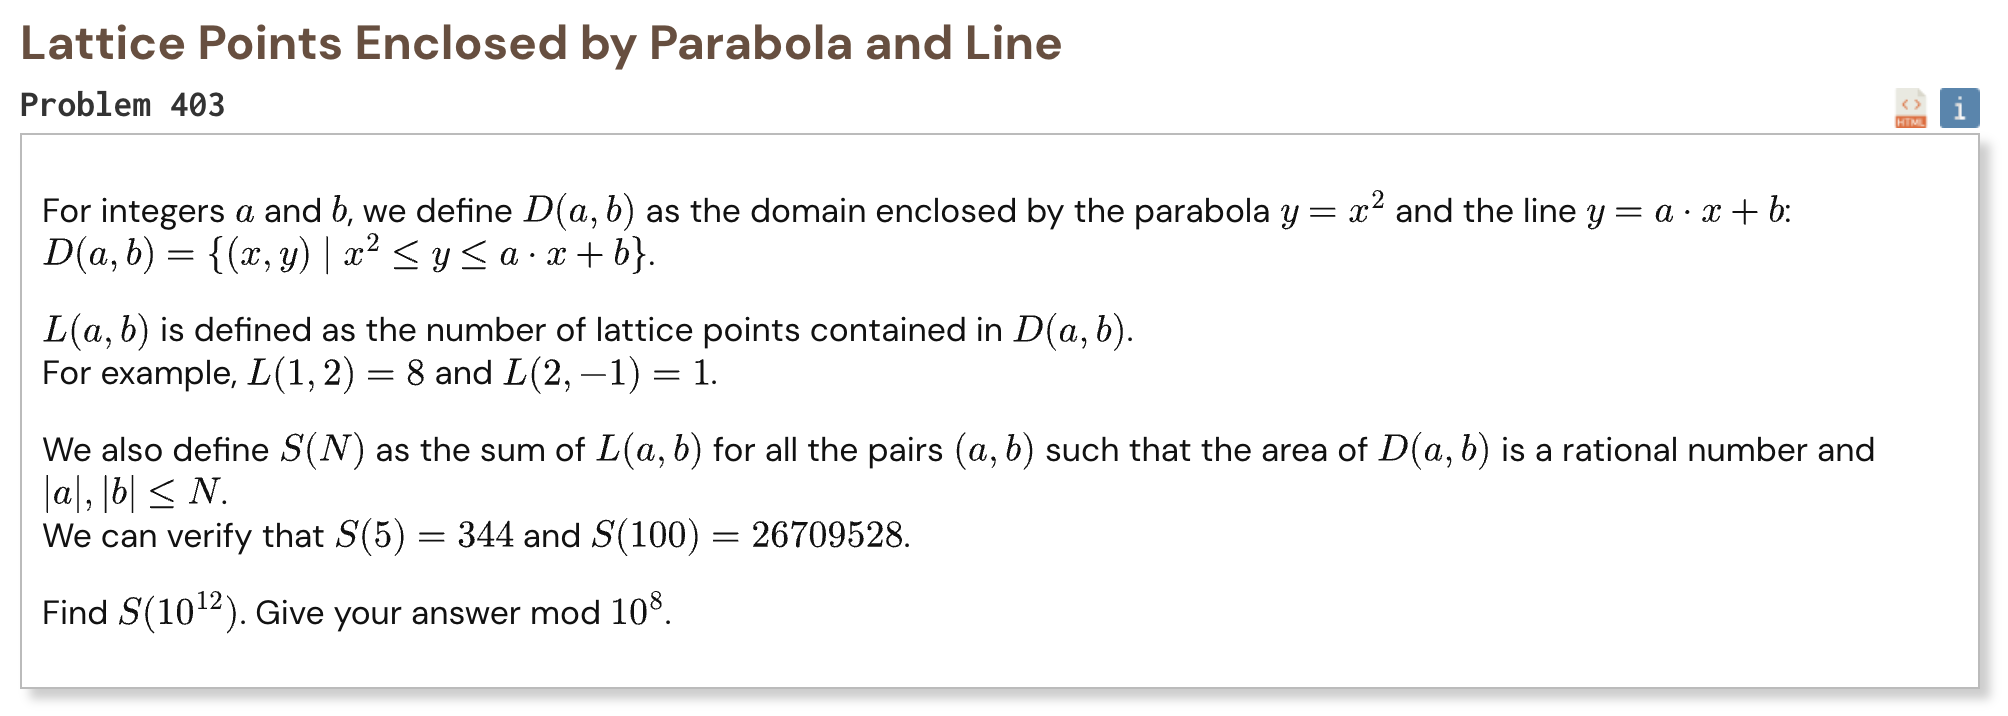

## Initial approach

- check when the parabola and line meet at suitable integer positions
- describe each valid region using its two intersection points
- count the lattice points one vertical column at a time
- notice that the count only depends on the distance between the intersections
- split the valid pairs into same sign and opposite sign cases
- use symmetry to avoid counting every pair separately
- group large ranges together so only about the square root of the limit is checked

In [1]:
%%time

from math import isqrt

MOD = 10**8
WORK_MOD = 6 * MOD

def sum_1(n):
    return n * (n + 1) // 2

def sum_2(n):
    return n * (n + 1) * (2 * n + 1) // 6

def sum_3(n):
    return sum_1(n) ** 2

def interval_sum(function, low, high):
    if low > high:
        return 0
    return function(high) - function(low - 1)

def lattice_numerator(c):
    return c**3 + 5 * c + 6

def shifted_sum(low, high, shift):
    if low > high:
        return 0

    count = high - low + 1
    first = interval_sum(sum_1, low, high)
    second = interval_sum(sum_2, low, high)
    third = interval_sum(sum_3, low, high)

    result = third
    result += 3 * shift * second
    result += 3 * shift * shift * first
    result += count * shift**3
    result += 5 * (first + count * shift)
    result += 6 * count

    return result % WORK_MOD

def calculate_s(n):
    limit = isqrt(n)

    total = 2 * shifted_sum(0, n, 0) - lattice_numerator(0)

    positive = 0
    for p in range(1, limit + 1):
        high = n // p
        positive += 2 * shifted_sum(p, high, p)
        positive -= lattice_numerator(2 * p)
        positive %= WORK_MOD

    negative = 0
    for u in range(1, limit + 1):
        high = min(n - u, n // u)
        negative += 2 * shifted_sum(u, high, -u)
        negative %= WORK_MOD

    numerator = (total + positive + negative) % WORK_MOD
    return numerator // 6

result = calculate_s(10**12)
print("Result:", result)

Result: 18224771
CPU times: user 4.43 s, sys: 31.5 ms, total: 4.46 s
Wall time: 4.48 s
